In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import autograd.numpy as np
import matplotlib.pyplot as plt
from autograd import grad, jacobian

from diffractix.elements import *
from diffractix.beams import GaussianBeam
from diffractix.system import System
import json


In [7]:
def plot_simulation(sim_result):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # We look at pairs of points: (current, next) with current != next
    # those are propagation segments
    for i in range(len(sim_result.trace) - 1):
        z_start, beam_start = sim_result.trace[i]
        z_end, _ = sim_result.trace[i+1]
        
        # If z doesn't change, it's a thin element (lens/interface) -> Skip drawing beam
        if np.isclose(z_start, z_end):
            continue
            
        # 50 points per segment
        z_local = np.linspace(0, z_end - z_start, 50)
        
        # Calculate width at these local offsets
        w_dense = np.array([beam_start.w_at_z(z, n=1.0) for z in z_local])
        
        z_global = z_start + z_local
        
        # plot beam 
        color = 'red' if beam_start.wavelength > 600e-9 else 'blue'
        ax.plot(z_global, w_dense * 1e3, color=color, alpha=0.8, lw=1) # Top edge
        ax.plot(z_global, -w_dense * 1e3, color=color, alpha=0.8, lw=1) # Bottom edge
        ax.fill_between(z_global, w_dense * 1e3, -w_dense * 1e3, color=color, alpha=0.1)

   
    # Formatting
    ax.set_xlabel("Position Z (m)")
    ax.set_ylabel("Beam Radius (mm)")
    ax.set_title(f"Gaussian Beam Propagation ($\lambda={sim_result.trace[0][1].wavelength*1e9:.0f}$ nm)")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jdyma\AppData\Local\Temp\ipykernel_2724\3784685164.py:32: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f"Gaussian Beam Propagation ($\lambda={sim_result.trace[0][1].wavelength*1e9:.0f}$ nm)")


=== Optical System Configuration (Compiled / Resolved) ===

--- Input Beams ---
  [0] GaussianBeam(lam=1.1 um, Current[w=1000.0 um, R=Plane], Waist[w0=1.0 mm @ z=-0.0 nm])

--- Component Schedule ---
#    Z-Pos      Type            Label                Parameters                                         Line
------------------------------------------------------------------------------------------------------------
0    0m         Space                                d=0.2, n=1                                         5
1    0.2m       ThinLens                             f=0.1[VAR]                                         6
2    0.2m       Space                                d=0.3[VAR], n=1[VAR]                               7
3    0.5m       ABCD                                 A=5[VAR], B=0, C=1, D=1, thickness=0, n=1          8
4    0.5m       Space                                d=0.2, n=1                                         9
5    0.7m       ThinLens                            

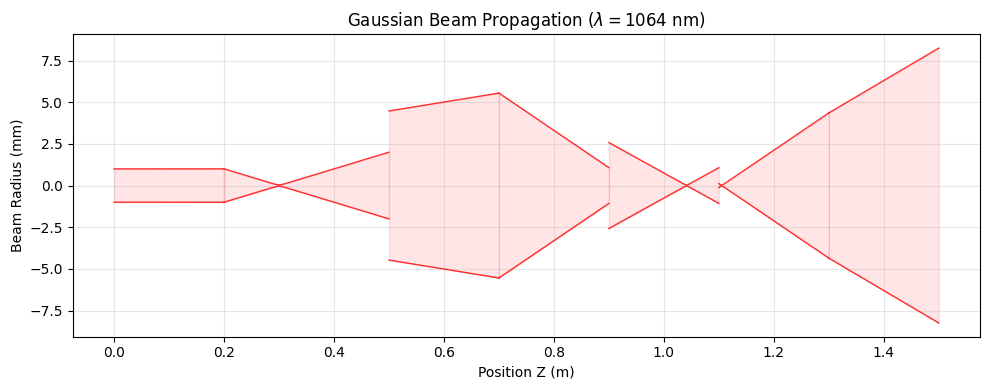

In [8]:
input_beam = GaussianBeam.from_waist(w0=1e-3, wavelength=1064e-9)

sys = System()
sys.add_input(input_beam)
sys.add(Space(d=0.2, ))
sys.add(ThinLens(f=0.1).variable())
sys.add(Space(d=0.3).variable())
sys.add(ABCD(A=5, C=1).variable('A'))
sys.add(Space(d=0.2))
sys.add(ThinLens(f=0.2).variable())
sys.add(Space(d=0.2, n=1.3))
sys.add(Slab(d=0.2, n = 1.5))
sys.add(Space(d=0.2))
sys.add(Mirror(R = 3))
sys.add(Space(d=0.2))
sim = sys.build()

print(sys)

print("Initial Parameters (Source_w0, Lens_f, Space_d):", sim.initial_params)
# print(sim.initial_params)

result = sim.run()
# print(json.dumps(result.export(), indent=2))

# expect output beam to have w = 0.001 and R = 0.1 at z = 0.4
plot_simulation(result)

--- BLUEPRINT ---
=== Optical System Configuration (Blueprint) ===

--- Input Beams ---
  [0] GaussianBeam(lam=1.1 um, Current[w=1000.0 um, R=Plane], Waist[w0=1.0 mm @ z=-0.0 nm])

--- Component Schedule ---
#    Z-Pos      Type            Label                Parameters                                         Line
------------------------------------------------------------------------------------------------------------
0    0m         Space           FixedEntry           d=0.2, n=1                                         8
1    0.2m       ThinLens        L1                   f=0.1[VAR]                                         9
2    0.2m       Space           Slider               d=0.3[VAR], n=1[VAR]                               12
3    0.5m       ABCD            BlackBox             A=5[VAR], B=0, C=1, D=1, thickness=0, n=1          13
4    0.5m       ThinLens        L2                   f=0.2[VAR]                                         17
5    0.5m       Space           Detector 

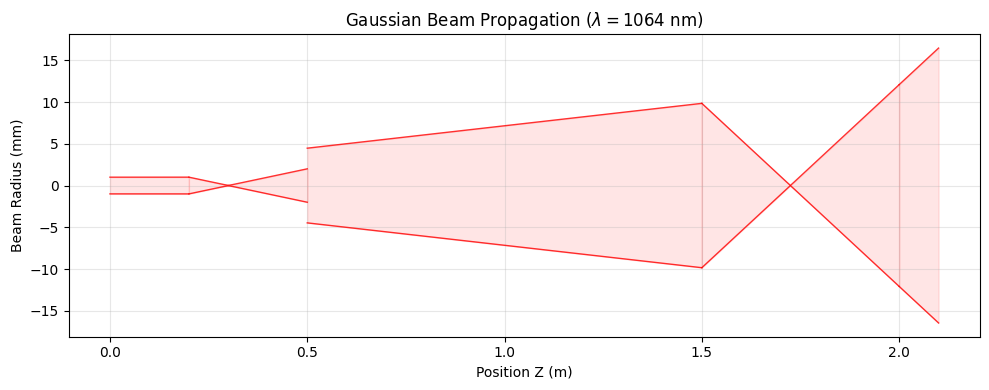


VERIFICATION COMPLETE: Layout logic and constraint generation are mathematically sound.


In [10]:
import numpy as np

# 1. Initialize System
sys = System()
sys.add_input(input_beam)

# --- SECTION 1: Relative/Sequential ---
sys.add(Space(d=0.2, label="FixedEntry"))
sys.add(ThinLens(f=0.1, label="L1").variable()) 

# --- SECTION 2: The "Loose" Chain ---
sys.add(Space(d=0.3, label="Slider").variable()) 
sys.add(ABCD(A=5, C=1, label="BlackBox").variable('A'))

# --- SECTION 3: The Anchor ---
# Target Z = 1.5m
sys.add(ThinLens(f=0.2, label="L2").variable(), z=1.5)

# --- SECTION 4: Final Anchor ---
# Target Z = 2.0m
sys.add(Space(d=0.1, label="Detector"), z=2.0)

print("--- BLUEPRINT ---")
print(sys)

# 2. Build the Simulation
sim = sys.build()

print("--- COMPILED (RESOLVED) ---")
print(sys)

# 3. Structural Info
print(f"Total Constraints Generated: {len(sim.constraints)}")

# 4. DIRECT CONSTRAINT VERIFICATION
print("\n--- Manual Constraint Verification ---")

# Execute the math-heavy pass
# data shape: (N_steps + 1, 3) -> [z, w, R]
print(sim.__dict__.keys())
data = sim.run_for_optimizer()

# We expect L2 to be at index 5 (Input + FixedEntry + L1 + Slider + BlackBox + AutoSpace)
# We expect Detector to be at index 7 (Above + L2 + AutoSpace)
anchors = [
    {"label": "L2 Anchor", "index": 5, "target": 1.5},
    {"label": "Detector Anchor", "index": 7, "target": 2.0}
]

all_passed = True
for anchor in anchors:
    actual_z = data[anchor['index'], 0]
    residual = (actual_z - anchor['target']) * 1e3 # convert to mm
    
    status = "✅" if abs(residual) < 1e-7 else "❌"
    print(f"{status} {anchor['label']}: Actual Z = {actual_z:.4f}m | Target = {anchor['target']:.4f}m | Residual = {residual:.8e} mm")
    
    if abs(residual) > 1e-7:
        all_passed = False

# 5. EXECUTE GENERATED CONSTRAINTS
# This tests if the lambda functions we built actually work
print("\n--- Lambda Constraint Verification ---")
for i, const_func in enumerate(sim.constraints):
    res = const_func(sim.initial_params, data)
    print(f"Lambda {i} Output: {res:.8f} mm")

# 6. Run Physics & Plot
result = sim.run()
plot_simulation(result)

if all_passed:
    print("\nVERIFICATION COMPLETE: Layout logic and constraint generation are mathematically sound.")

GaussianBeam(lam=1.1 um, Current[w=1000.0 um, R=Plane], Waist[w0=1.0 mm @ z=-0.0 nm])
Initial Parameters (Source_w0, Lens_f, Space_d): [0.2 1.  0.1 0.3 1.  0.2 0.2 1. ]
{
  "structure": null,
  "results": [
    {
      "wavelength": 1.064e-06,
      "z": [
        0.0,
        0.2,
        0.2,
        0.5,
        0.5,
        0.7
      ],
      "w": [
        0.0009999999999999998,
        0.0010022914806924533,
        0.001002291480692453,
        0.0020002867427114466,
        0.0020002867427114466,
        0.0020011467243229997
      ],
      "R": [
        Infinity,
        43.78996234016088,
        -0.10022888552574481,
        0.19994268022105574,
        697.6393974428814,
        349.11969872136405
      ]
    }
  ]
}


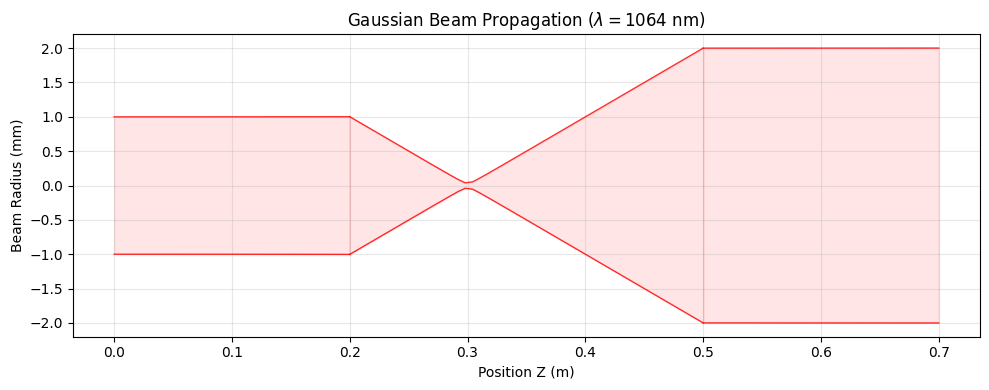

In [13]:
sys = System()

input_beam = GaussianBeam.from_waist(w0=1e-3, wavelength=1064e-9)
print(input_beam)
sys.add_input(input_beam)

sys.add(Space(d=0.2, label="Drift Region"))
sys.add(ThinLens(f=0.1, label="Focus Lens"))
sys.add(Space(d=0.3, label="Drift Region"))
sys.add(ThinLens(f=0.2, label="Focus Lens"))
sys.add(Space(d=0.2, label="Drift Region"))

sim = sys.build()

print("Initial Parameters (Source_w0, Lens_f, Space_d):", sim.initial_params)
# print(sim.initial_params)

result = sim.run()
print(json.dumps(result.export(), indent=2))

# expect output beam to have w = 0.001 and R = 0.1 at z = 0.4
plot_simulation(result)

# Optimization Test

In [8]:
class Optimizer: 
    def __init__(self, max_iters=100, tol=1e-10, initial_damping=1e-3, verbose=True):
        self.max_iters = max_iters
        self.tol = tol
        self.lambda_damping = initial_damping
        self.verbose = verbose

    def optimize(self, residual_func, initial_vars):
        current_vars = initial_vars.copy()
        r_hist = []
        param_hist = []

        jac_func = jacobian(residual_func)
        
        # iterative optimization loop
        for i in range(self.max_iters):
            delta, r, J = self._lm_step(residual_func, jac_func, current_vars)

            error = np.sum(r**2)
            if self.verbose: 
                print(f"Iter {i}: Error {error:.2e}, Vals {current_vars}")
                print("Delta: ", delta)
            if error < self.tol:
                print(f"Converged after {i} steps")
                break

            r_hist.append(r)
            param_hist.append(current_vars.copy())
            current_vars += delta

        if error >= self.tol:
            print(f"Did not converge after {i} steps")

        param_hist.append(current_vars.copy())
        print(f"Final Parameters: {current_vars}")
        print(f"Final Residuals: {r}")
        return current_vars, r_hist, param_hist


    def _lm_step(self, residual_func, jac_func, current_vars):
        # Calculate Residuals and Jacobian
        r = residual_func(current_vars)
        J = jac_func(current_vars)
        
        # perform Levenberg-Marquardt step
        # delta = -(J.T*J + lambda*I)^-1 * J.T * r
        H = J.T @ J
        damping_matrix = self.lambda_damping * np.eye(len(current_vars))
        
        A = H + damping_matrix
        b = -J.T @ r
       
        try:
            delta = -np.linalg.solve(H + damping_matrix, J.T @ r)
        except np.linalg.LinAlgError:
            delta = np.linalg.lstsq(A, b, rcond=None)[0]

    
        return delta, r, J

In [14]:
import autograd.numpy as np
from autograd import jacobian


# this one has adapring dampening rate - curtesy of LLM
class Optimizer: 
    def __init__(self, max_iters=100, tol=1e-10, initial_damping=1e-3, verbose=True):
        self.max_iters = max_iters
        self.tol = tol
        self.lambda_damping = initial_damping
        self.verbose = verbose

    def optimize(self, residual_func, initial_vars):
        current_vars = initial_vars.copy()
        r_hist = []
        param_hist = []

        # JIT-compile the Jacobian function
        jac_func = jacobian(residual_func)
        
        # 1. Calculate Initial State (Before loop)
        r = residual_func(current_vars)
        J = jac_func(current_vars)
        current_error = np.sum(r**2)
        
        if self.verbose: print(f"Start Error: {current_error:.2e}")

        # Main Loop
        for i in range(self.max_iters):
            
            # --- The Retry Loop (Critical for Stability) ---
            # We stay in this loop until we find a step that reduces error
            step_accepted = False
            
            while not step_accepted:
                
                # A. Calculate Delta (Math)
                delta = self._calc_delta(J, r, self.lambda_damping)
                
                # B. Test the Candidate
                candidate_vars = current_vars + delta
                candidate_r = residual_func(candidate_vars)
                candidate_error = np.sum(candidate_r**2)
                
                # C. Accept/Reject Logic
                if candidate_error < current_error:
                    # ACCEPT
                    # 1. Update State
                    current_vars = candidate_vars
                    current_error = candidate_error
                    r = candidate_r
                    
                    # 2. Update Jacobian for the NEW position
                    # (We only pay the cost of J calc when we actually move)
                    J = jac_func(current_vars)
                    
                    # 3. Decrease Damping (Trust the gradient more)
                    self.lambda_damping = max(1e-9, self.lambda_damping / 10.0)
                    step_accepted = True
                    
                else:
                    # REJECT
                    # 1. Do NOT move current_vars
                    # 2. Increase Damping (Trust gradient less, step smaller)
                    self.lambda_damping *= 10.0
                    
                    if self.verbose:
                        print(f"  > Step rejected (Err {candidate_error:.2e}). Lambda -> {self.lambda_damping:.1e}")
                    
                    # Failsafe
                    if self.lambda_damping > 1e20:
                        print("Optimization Failed: Damping too high.")
                        return current_vars, r_hist, param_hist

            # --- Logging & History ---
            if self.verbose: 
                print(f"Iter {i}: Error {current_error:.2e}, Lambda {self.lambda_damping:.1e}")

            r_hist.append(r)
            param_hist.append(current_vars.copy())

            # Convergence Check
            if current_error < self.tol:
                print(f"Converged after {i} steps")
                break
        
        if current_error >= self.tol:
            print(f"Did not converge after {self.max_iters} steps")

        print(f"Final Parameters: {current_vars}")
        print(f"Final Residuals: {r}")
        return current_vars, r_hist, param_hist

    def _calc_delta(self, J, r, lambda_damping):
        """
        Pure math helper. Calculates the step size delta.
        """
        # Hessian Approximation
        H = J.T @ J
        
        # Damping Matrix
        # Ensure eye matches number of PARAMETERS (columns of J)
        n_params = J.shape[1] 
        damping_matrix = lambda_damping * np.eye(n_params)
        
        # Linear System
        A = H + damping_matrix
        b = -J.T @ r
        
        try:
            delta = -np.linalg.solve(H + damping_matrix, J.T @ r)
        except np.linalg.LinAlgError:
            delta = np.linalg.lstsq(A, b, rcond=None)[0]
        
        return delta

Initial Parameters:
[0.2 1.  0.3 0.1 1.  0.1 0.2 1. ]


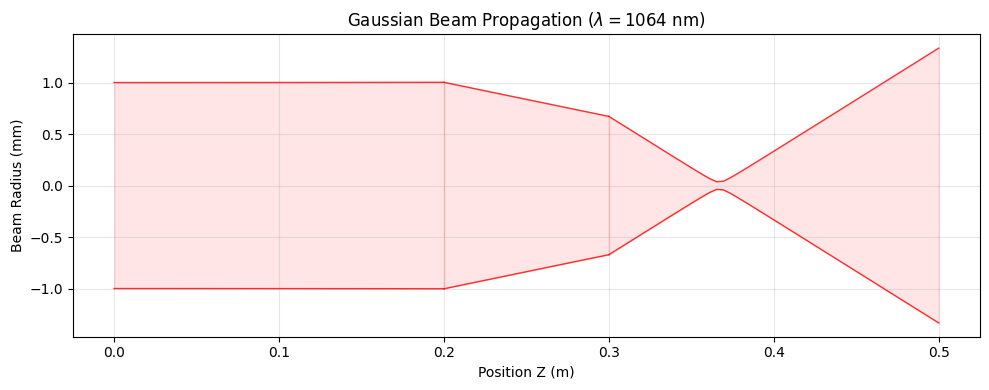

In [15]:
sys = System()

# Input: 1mm beam, 1064nm
sys.add_input(GaussianBeam.from_waist(w0=1e-3, wavelength=1064e-9))

# structure: Space -> Lens(f=0.1) -> Space -> Lens(f=0.2) -> Space
# initialize with wrong values (initial guess)
sys.add(Space(d=0.2, label="In-Leg"))      # Index 1 (extra space to observe output)
sys.add(ThinLens(f=0.3, label="L1"))              # Index 2 (wrong Should be 0.1)
sys.add(Space(d=0.1, label="Mid-Leg"))    # Index 3 (wrong Should be f1+f2 = 0.3)
sys.add(ThinLens(f=0.1, label="L2"))           # Index 4 (Wrong! Should be 0.2)
sys.add(Space(d=0.2, label="Out-Leg"))     # Index 5 (extra space to observe output)

sim = sys.build()

print("Initial Parameters:")
# Map indices manually for this test (then elements)
# [d1, f1, d2, f2, d3]
print(sim.initial_params) 

result = sim.run()
plot_simulation(result)

Initial Guess: [1.  0.3 0.1]
Converged after 7 steps
Final Parameters: [1.00002658 0.05006263 0.15011279]
Final Residuals: [-1.25477656e-11  1.08420217e-13  0.00000000e+00]


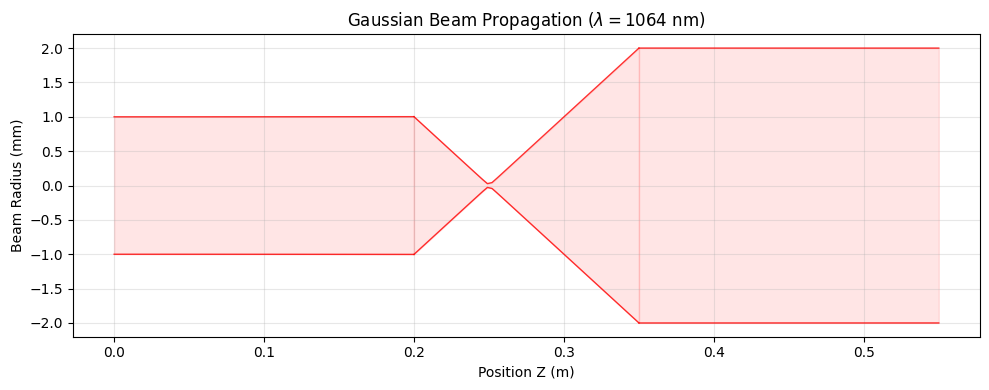

{
  "structure": null,
  "results": [
    {
      "wavelength": 1.064e-06,
      "z": [
        0.0,
        0.2,
        0.2,
        0.3501127878058236,
        0.3501127878058236,
        0.5501127878058236
      ],
      "w": [
        0.0009999999999999998,
        0.001002291359043665,
        0.001002291359043665,
        0.0020002867427164756,
        0.002000286742716475,
        0.002000000000000011
      ],
      "R": [
        Infinity,
        43.79111543475398,
        -0.050119925126139935,
        0.10001433610793047,
        -697.6393913408336,
        -79695463964.7562
      ]
    }
  ]
}


In [22]:
# define which parameters are variable/fixed
# indices: 0(d1), 1(f1), 2(d2), 3(f2), 4(d3)
variable_indices = [1, 2, 3]
fixed_params = sim.initial_params.copy()

def residual_func(variable_params):
    # 1. Reconstruct Full Array (List method for Autograd safety)
    full_params_list = list(fixed_params)
    for i, param_idx in enumerate(variable_indices):
        full_params_list[param_idx] = variable_params[i]
    
    full_params = np.array(full_params_list)
    
    # 2. Run Sim
    data = sim.run_for_optimizer(full_params)
    
    # 3. Calculate Physics Residuals
    w_final = data[-1, 1]
    R_final = data[-1, 2]
    
    # Target A: Collimation (1/R = 0)
    # Unit: Diopters (1/m). 
    r_collimation = (1.0 / R_final) * 1.0 
    
    # Target B: Waist Size = 0.2mm
    # Unit: Meters. We scale by 1e3 (mm) or 1e4 to make it comparable to Diopters
    target_waist = 2e-3
    r_size = (w_final - target_waist) * 1e4 
    
    # 4. Parameter Constraints (Soft Barriers)
    # Prevent negative lengths AND negative focal lengths (keep lens convex)
    # logic: sum(max(0, -val)) -> error if val is negative
    r_pos = np.sum(np.maximum(0, -variable_params)) * 1e5
    
    return np.array([r_collimation, r_size, r_pos])


current_vars = fixed_params[variable_indices]
print(f"Initial Guess: {current_vars}")

optimizer = Optimizer(max_iters=1000, tol=1e-12, initial_damping=1e-3, verbose=False)
optimized_vars, r_history, param_hist = optimizer.optimize(residual_func, current_vars)

final_params = sim.initial_params.copy()
final_params[variable_indices] = optimized_vars

result = sim.run(final_params)
plot_simulation(result)

print(json.dumps(result.export(), indent=2))

# Animate & Plot

In [21]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Setup the Figure ONCE
fig, ax = plt.subplots(figsize=(10, 4))

# We run the FINAL simulation first to set the axis limits correctly
# This ensures the view doesn't jump around during the animation
final_params = sim.initial_params.copy()
final_params[variable_indices] = param_hist[-1]
final_res = sim.run(final_params)

# Extract limits from final result
all_z = []
all_w = []
for i in range(len(final_res.trace) - 1):
    z_s, b_s = final_res.trace[i]
    z_e, _ = final_res.trace[i+1]
    all_z.extend([z_s, z_e])
    all_w.append(b_s.w_at_z(0)*1e3)

ax.set_xlim(min(all_z), max(all_z))
ax.set_ylim(-max(all_w)*3.0, max(all_w)*3.0) # Give some headroom

# Formatting (Static)
ax.set_xlabel("Position Z (m)")
ax.set_ylabel("Beam Radius (mm)")
ax.grid(True, alpha=0.3)
title_text = ax.set_title(f"Optimization Start")

# Add Target Lines (Static)
ax.axhline(2.0, color='k', linestyle=':', alpha=0.5, label='Target (2mm)')
ax.axhline(-2.0, color='k', linestyle=':', alpha=0.5)

# Container to track the artists (lines/shapes) we draw so we can remove them next frame
current_artists = []

# 2. Define the Update Function
def update(frame_idx):
    # A. Clear previous frame's beam
    for artist in current_artists:
        artist.remove()
    current_artists.clear()
    
    # B. Get parameters for this history step
    current_vars = param_hist[frame_idx]
    frame_params = sim.initial_params.copy()
    frame_params[variable_indices] = current_vars
    
    # C. Run Simulation
    sim_result = sim.run(frame_params)
    
    # D. Draw Beam (Your Custom Logic)
    # We look at pairs of points: (current, next)
    for i in range(len(sim_result.trace) - 1):
        z_start, beam_start = sim_result.trace[i]
        z_end, _ = sim_result.trace[i+1]
        
        # Skip thin elements
        if np.isclose(z_start, z_end):
            continue
            
        # 50 points per segment
        z_local = np.linspace(0, z_end - z_start, 50)
        
        # Calculate width
        w_dense = np.array([beam_start.w_at_z(z, n=1.0) for z in z_local])
        z_global = z_start + z_local
        
        # Plot beam
        color = 'red' if beam_start.wavelength > 600e-9 else 'blue'
        
        # We save the artists to our list so we can remove them later
        l1, = ax.plot(z_global, w_dense * 1e3, color=color, alpha=0.8, lw=1)
        l2, = ax.plot(z_global, -w_dense * 1e3, color=color, alpha=0.8, lw=1)
        poly = ax.fill_between(z_global, w_dense * 1e3, -w_dense * 1e3, color=color, alpha=0.1)
        
        current_artists.extend([l1, l2, poly])

    # Update Title
    title_text.set_text(f"Optimization Step {frame_idx}/{len(param_hist)-1}")
    
    return current_artists + [title_text]

# 3. Create Animation
anim = FuncAnimation(fig, update, frames=len(param_hist), interval=100, blit=False)

# 4. Display
plt.close() # Prevent duplicate plot
HTML(anim.to_jshtml())

In [230]:
anim.save(
    "optimization.gif",
    fps=30
)

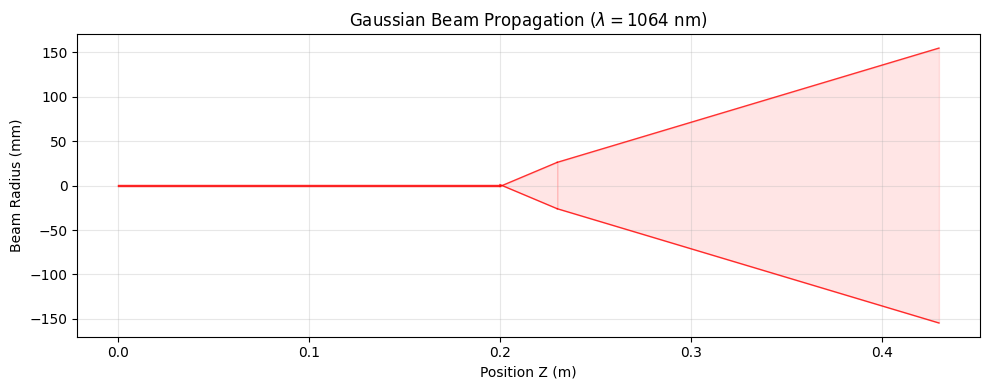

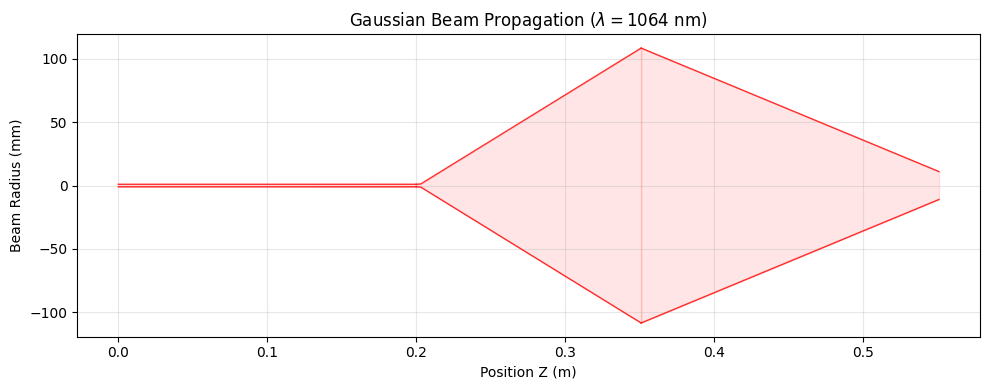

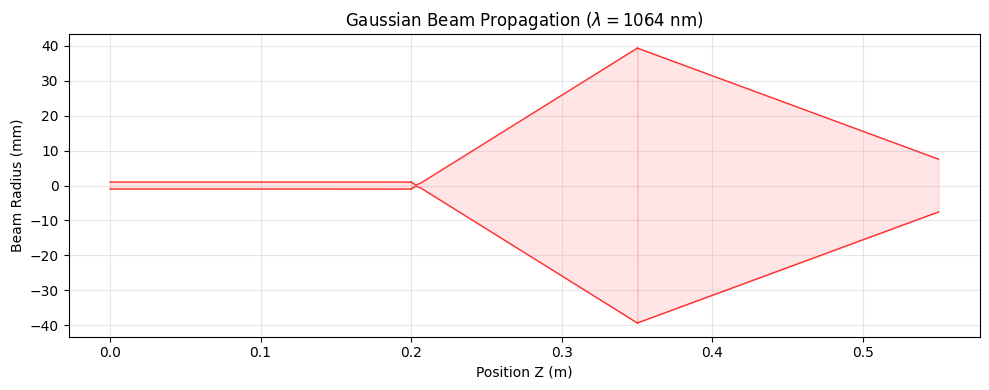

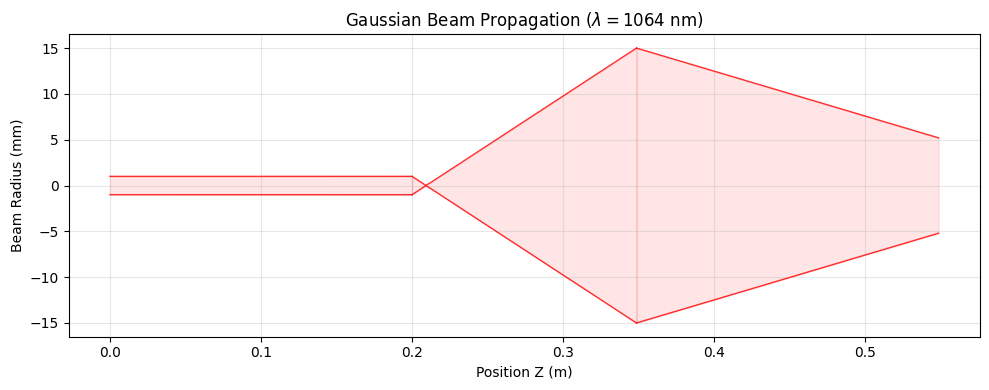

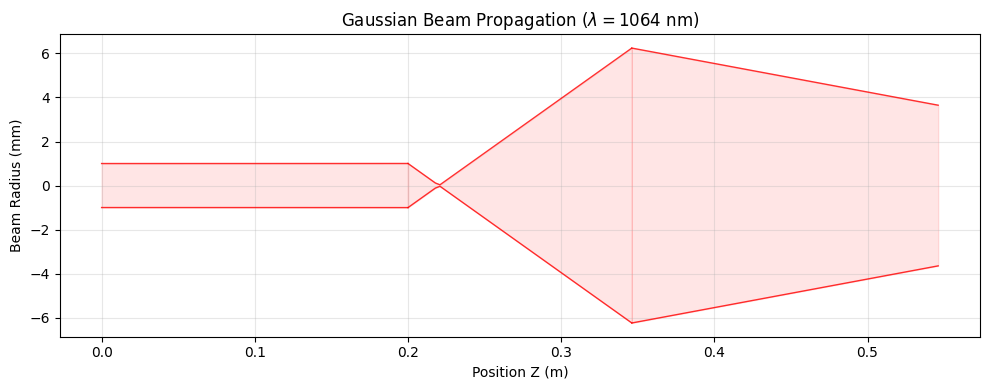

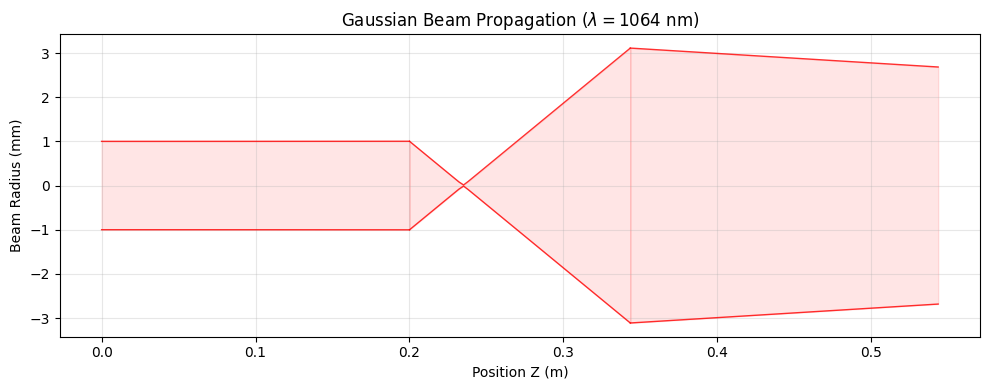

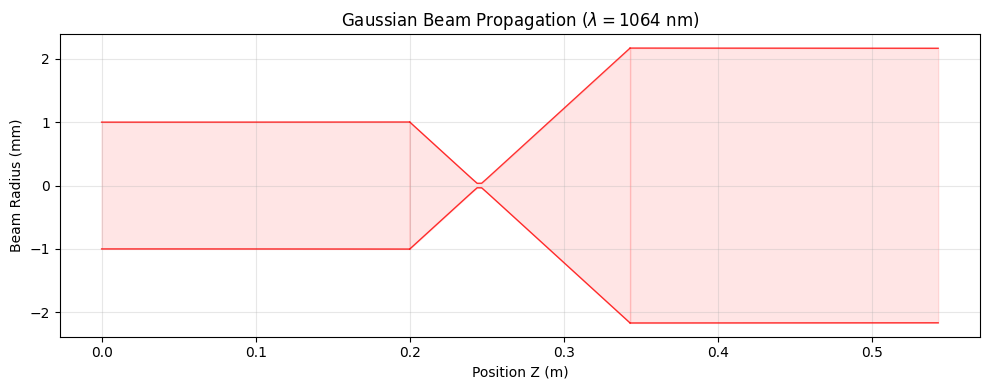

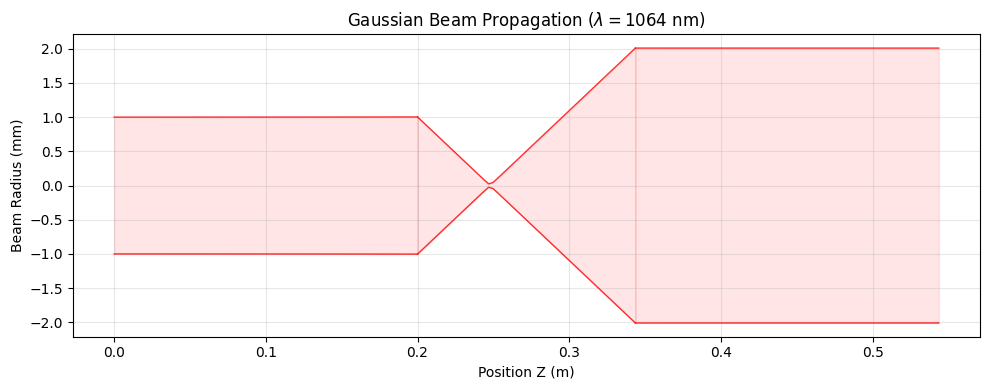

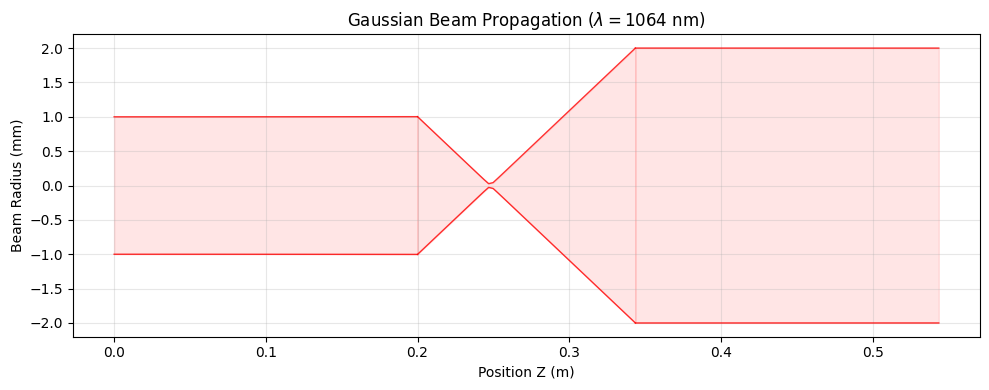

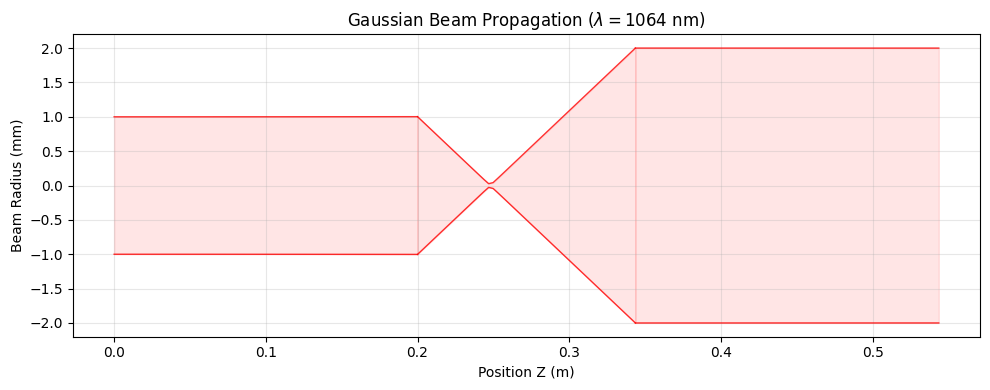

In [108]:

for param in param_hist:
    final_params = sim.initial_params.copy()
    final_params[variable_indices] = param

    result = sim.run(final_params)
    plot_simulation(result)

